In [486]:
import numpy as np
import pandas as pd

In [488]:
df = pd.read_csv('https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv')

In [490]:
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


This is the dataset on which we are performing sentiment analysis

In [493]:
df.shape

(37249, 2)

In [494]:
df.sample()["clean_comment"].values

array(['aamir liaquat '], dtype=object)

In [495]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37249 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_comment  37149 non-null  object
 1   category       37249 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 582.1+ KB


In [496]:
df.isnull().sum()

clean_comment    100
category           0
dtype: int64

There are 100 rows in which comment is missing

In [502]:
df[df["clean_comment"].isna()]

,clean_comment,category
413,NaN,0
605,NaN,0
2422,NaN,0
2877,NaN,0
3307,NaN,0
...,...,...
35975,NaN,0
36036,NaN,0
37043,NaN,0
37111,NaN,0


In [504]:
df[df["clean_comment"].isna()]["category"].value_counts()

category
0    100
Name: count, dtype: int64

In [506]:
df["category"].value_counts()

category
 1    15830
 0    13142
-1     8277
Name: count, dtype: int64

So there will be no problem even if we delete those 100 rows

In [509]:
df.dropna(inplace=True)

In [511]:
df.duplicated().sum()

np.int64(350)

In [513]:
df[df.duplicated()]

,clean_comment,category
375,,0
392,,0
617,aurum mom,0
651,,0
1222,,0
...,...,...
36915,who won,0
37044,,0
37125,hari,0
37158,top kek,1


We will delete these too

In [516]:
df.drop_duplicates(inplace=True)

In [518]:
df.duplicated().sum()

np.int64(0)

So now we will see if there exists comments which are like having no text at all

In [521]:
df[df["clean_comment"].str.strip() == ""]

,clean_comment,category
181,,0
4432,\n,0
10592,,0
16173,,0
32149,\n,0
34959,,0


We will remove these too

In [524]:
df = df[~(df["clean_comment"].str.strip() == "")]

In [525]:
df[df["clean_comment"].str.strip() == ""]

,clean_comment,category


Now we will perform some basic eda on this

In [529]:
#convert 'clean_comment' column to lower case
df["clean_comment"] = df["clean_comment"].str.lower()

#Removing trailing and leading whitespaces from 'clean_comment" column
df["clean_comment"] = df["clean_comment"].str.strip()

In [530]:
df['clean_comment'].apply(lambda x: x.endswith(' ') or x.startswith(' ')).sum()

np.int64(0)

Now there 0 rows with trailing or leading spaces

In [532]:
# Identify comments containing URLs
url_pattern = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
comments_with_urls = df[df['clean_comment'].str.contains(url_pattern, regex=True)]

In [533]:
comments_with_urls

,clean_comment,category


There are no comments which contains urls so there is no need to write another function to delete them

In [539]:
# Identify comments containing new line characters
comments_with_newline = df[df['clean_comment'].str.contains('\n')]
comments_with_newline

,clean_comment,category
448,what missing jpg\nand why this brilliant edit ...,1
781,india has been ruined congress and populist sc...,-1
847,like aap for its stand corruption and making p...,-1
871,reduced trade\ndeficit stronger rupee aren the...,0
1354,amsa press conference australian maritime safe...,1
...,...,...
35128,火箭o辛基 2016 sughosh bansal mission “make india”...,-1
35230,yikes the title should blind bhakts modi hater...,1
36187,hahahahahhahahah \niska klpd hogya,0
36517,्ा् ी ाी े ो ेी ाी े।\nे ी,0


There are 204 comments which contain new line we need to remove that new line and instead we will introduce space there

In [542]:
df['clean_comment'] = df['clean_comment'].str.replace('\n', ' ', regex=True)

In [544]:
df["clean_comment"].head()

0    family mormon have never tried explain them th...
1    buddhism has very much lot compatible with chr...
2    seriously don say thing first all they won get...
3    what you have learned yours and only yours wha...
4    for your own benefit you may want read living ...
Name: clean_comment, dtype: object

Now we will start EDA

# EDA

In [547]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='category', ylabel='count'>

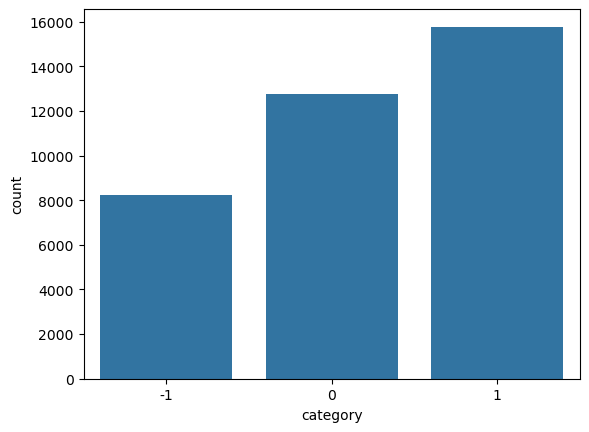

In [548]:
#distribution of classes
sns.countplot(data=df , x="category")

In [549]:
df["category"].value_counts(normalize=True).mul(100).round(2)

category
 1    42.86
 0    34.71
-1    22.42
Name: proportion, dtype: float64

So there are 42.86% comments with category '1' 34.71% with category with category '0' and 22.42% with category '-1'

Now we will analyze about number of words in each comment for that we will create new column named word_count

In [552]:
df["word_count"] = df['clean_comment'].apply(lambda x: len(x.split()))

In [553]:
df.head()

,clean_comment,category,word_count
0,family mormon have never tried explain them th...,1,39
1,buddhism has very much lot compatible with chr...,1,196
2,seriously don say thing first all they won get...,-1,86
3,what you have learned yours and only yours wha...,0,29
4,for your own benefit you may want read living ...,1,112


In [554]:
df["word_count"].describe()

count    36793.000000
mean        29.667464
std         56.790738
min          1.000000
25%          6.000000
50%         13.000000
75%         30.000000
max       1307.000000
Name: word_count, dtype: float64

In [555]:
df[df["word_count"] > 100].shape[0]

1871

There are 1871 comments with number of words greater than 100

To understand it better we will plot it

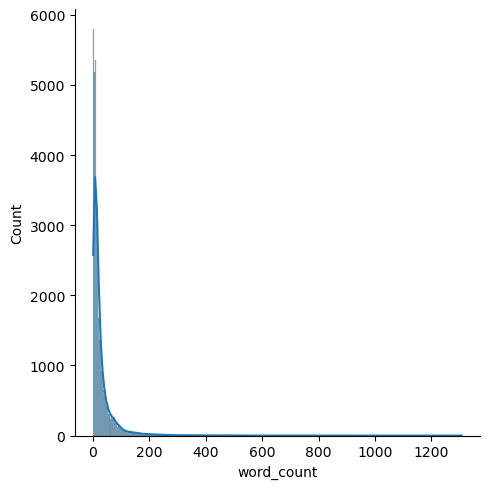

In [558]:
sns.displot(df['word_count'], kde=True)

Well we can see many of the comments have less than 200

In [562]:
df[df["word_count"] > 200].shape[0]

602

There are significant number of comments which have word_count greater than 200

Now we will analyze word_count within it's specific category

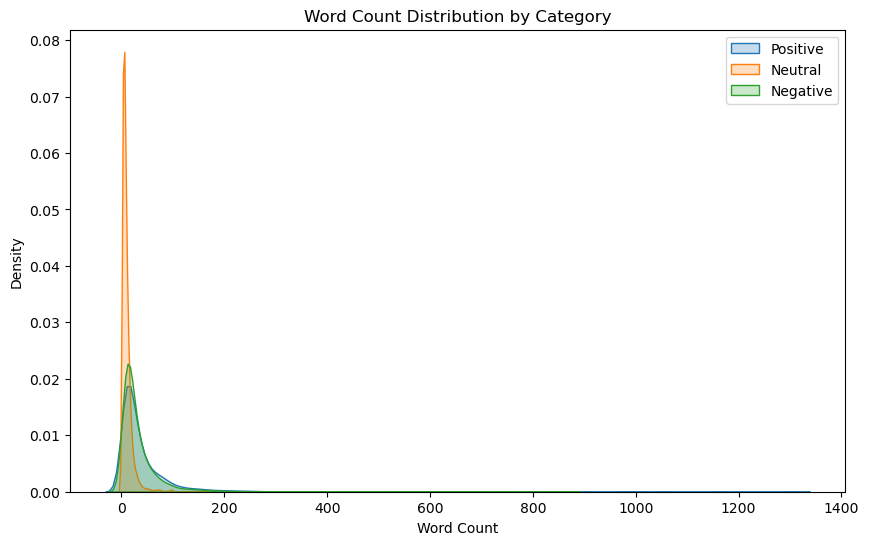

In [571]:
plt.figure(figsize=(10, 6))

sns.kdeplot(df[df['category'] == 1]['word_count'], label='Positive', fill=True)

sns.kdeplot(df[df['category'] == 0]['word_count'], label='Neutral', fill=True)

sns.kdeplot(df[df['category'] == -1]['word_count'], label='Negative', fill=True)

plt.title('Word Count Distribution by Category')
plt.xlabel('Word Count')
plt.ylabel('Density')

plt.legend()

plt.show()

We can draw some useful observations from this plot  
1.Positive comments have a wider spread in word count, indicating that longer comments are more common in positive sentiments  
2.Negative comments have a similar distribution as Positive comments  
3.Neutral comments are concentrated around shorter comments I mean all of them have comments less than size 200

<Axes: ylabel='word_count'>

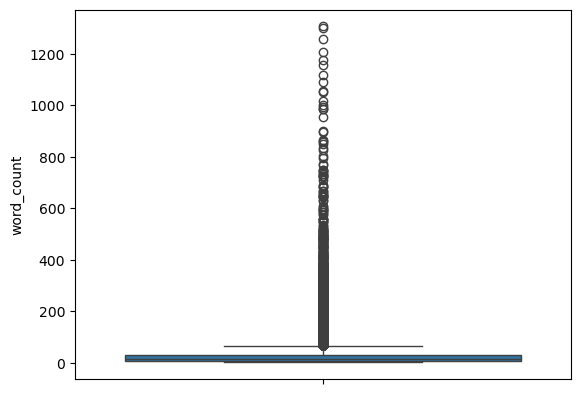

In [573]:
sns.boxplot(df["word_count"])

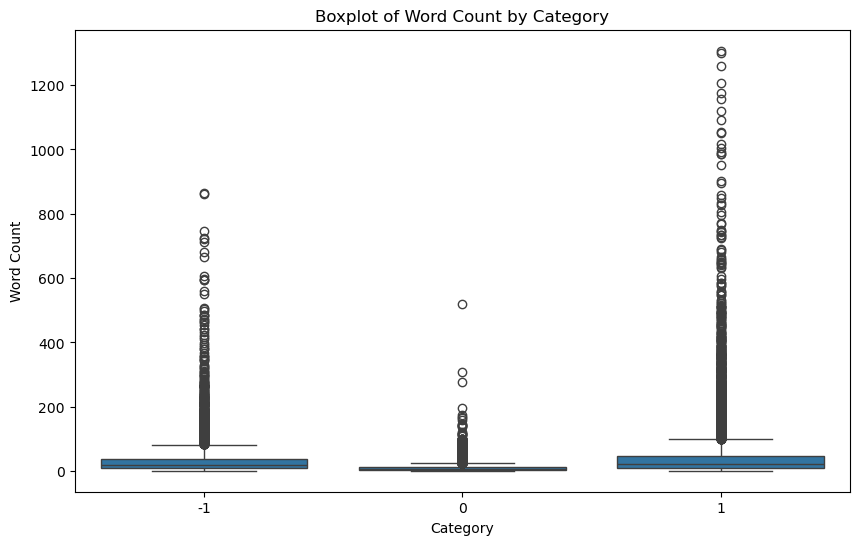

In [574]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='category', y='word_count')
plt.title('Boxplot of Word Count by Category')
plt.xlabel('Category')
plt.ylabel('Word Count')
plt.show()

<Axes: xlabel='category', ylabel='word_count'>

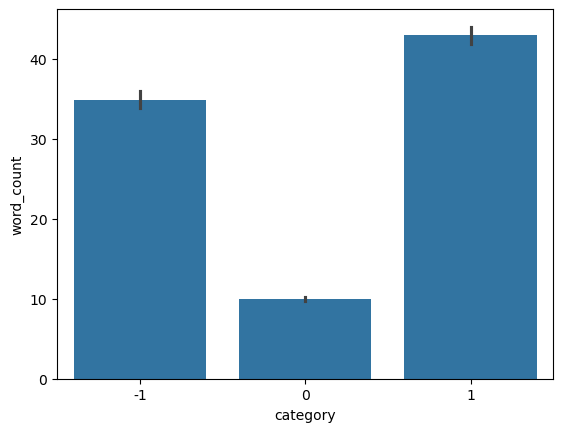

In [575]:
sns.barplot(df , x="category" , y="word_count" , estimator="mean")

<Axes: xlabel='category', ylabel='word_count'>

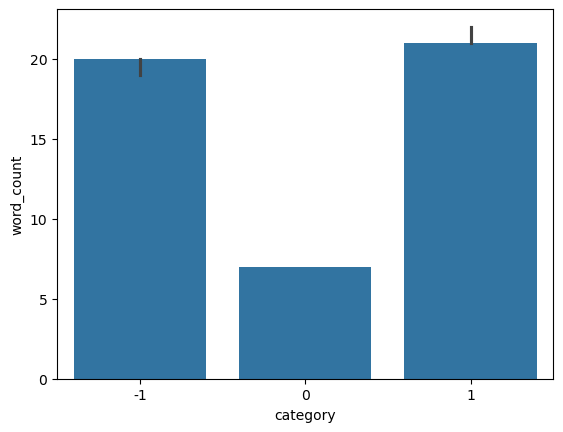

In [576]:
sns.barplot(df , x="category" , y="word_count" , estimator="median")

Well we can clearly see the fact that we have mentioned before neutral comments have relatively lesser words compared to positive and negative

Now we will analyze about stop words

In [579]:
import nltk
from nltk.corpus import stopwords

In [581]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\saini\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [582]:
stop_words = set(stopwords.words("english"))

We will create new column 'num_stop_words' by counting number of stopwords in each comment

In [584]:
df['num_stop_words'] = df['clean_comment'].apply(lambda x: len([word for word in x.split() if word in stop_words]))

In [585]:
df.sample(5)

,clean_comment,category,word_count,num_stop_words
36969,the fuck actually said that shit the video,-1,8,3
34908,oddly agreeable,-1,2,0
34735,notice how all the evidence are from indian so...,-1,63,28
18894,grandissimo perfetta,0,2,0
18411,hmm every year its the same thing this team lo...,1,243,93


We will go in similar way as we did with 'count_words' column

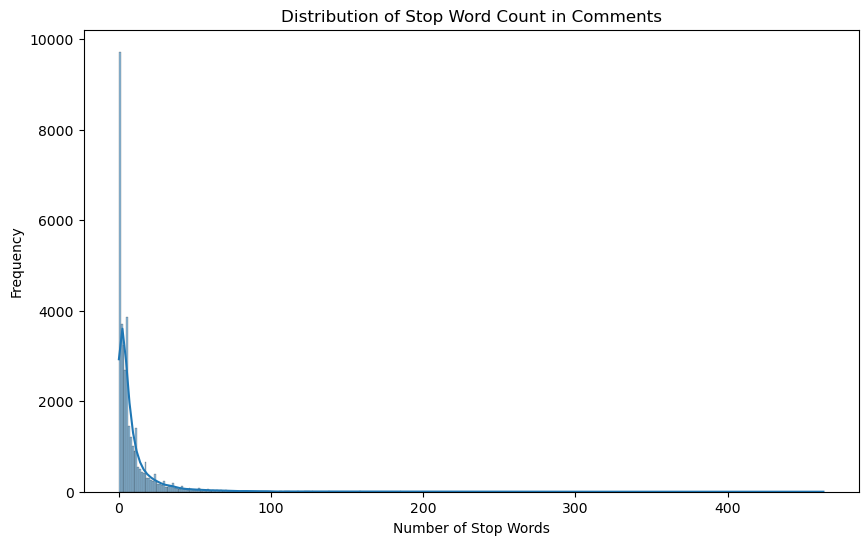

In [587]:
plt.figure(figsize=(10, 6))
sns.histplot(df['num_stop_words'], kde=True)
plt.title('Distribution of Stop Word Count in Comments')
plt.xlabel('Number of Stop Words')
plt.ylabel('Frequency')
plt.show()

Almost all of the comments have number of stopwords less than 100

Now we will do it for each category

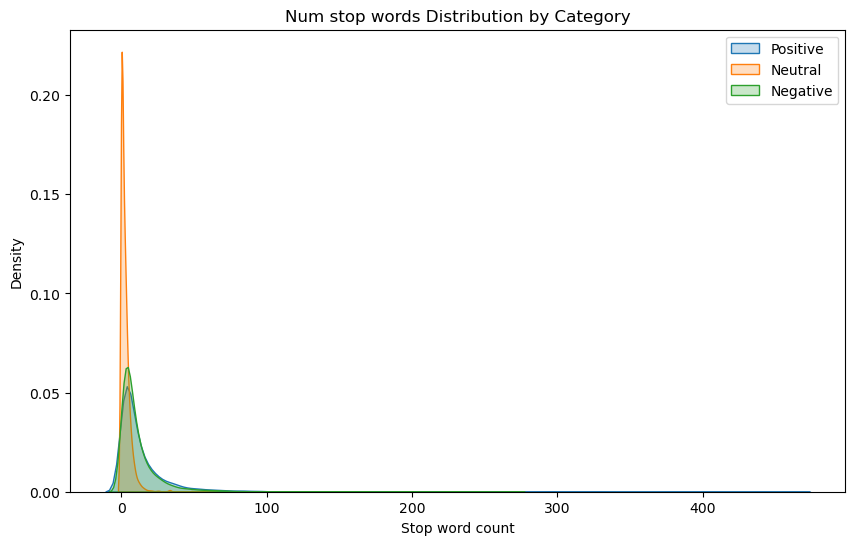

In [590]:
plt.figure(figsize=(10, 6))

sns.kdeplot(df[df['category'] == 1]['num_stop_words'], label='Positive', fill=True)

sns.kdeplot(df[df['category'] == 0]['num_stop_words'], label='Neutral', fill=True)

sns.kdeplot(df[df['category'] == -1]['num_stop_words'], label='Negative', fill=True)

plt.title('Num stop words Distribution by Category')
plt.xlabel('Stop word count')
plt.ylabel('Density')

plt.legend()

plt.show()

The plot is almost similar to the plot we got for 'word_count'

<Axes: xlabel='category', ylabel='num_stop_words'>

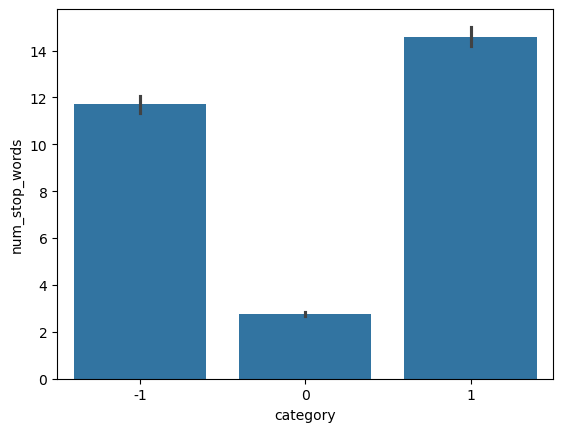

In [592]:
sns.barplot(df , x="category" , y="num_stop_words" , estimator="mean")

<Axes: xlabel='category', ylabel='num_stop_words'>

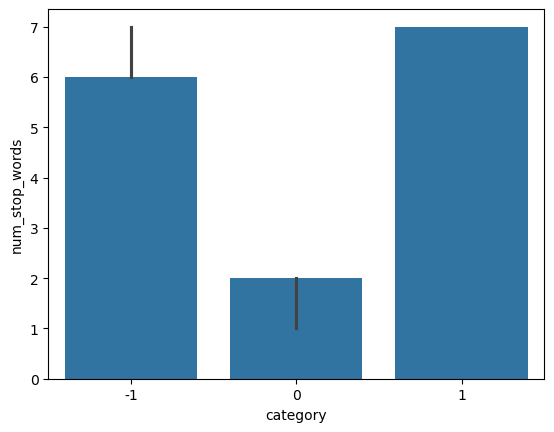

In [593]:
sns.barplot(df , x="category" , y="num_stop_words" , estimator="median")

C:\Users\saini\AppData\Local\Temp\ipykernel_3768\355666877.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_df, x='count', y='stop_word', palette='viridis')


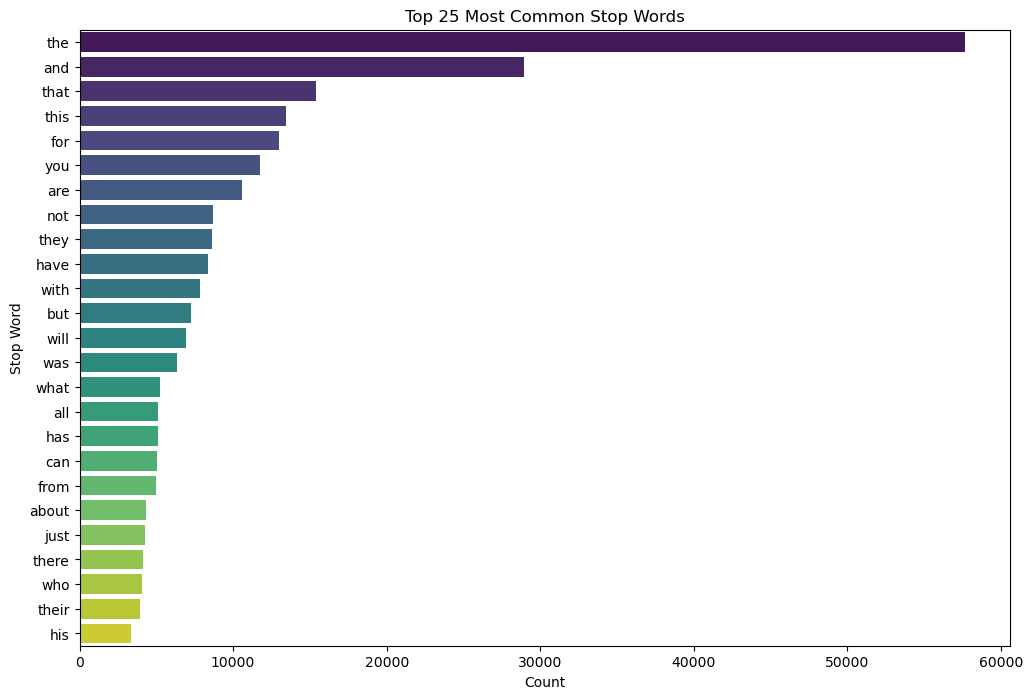

In [594]:
from collections import Counter

all_stop_words = [word for comment in df['clean_comment'] for word in comment.split() if word in stop_words]

most_common_stop_words = Counter(all_stop_words).most_common(25)

top_25_df = pd.DataFrame(most_common_stop_words, columns=['stop_word', 'count'])

plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_df, x='count', y='stop_word', palette='viridis')
plt.title('Top 25 Most Common Stop Words')
plt.xlabel('Count')
plt.ylabel('Stop Word')
plt.show()

These are top 25 most occuring stop words

Now we will analyze characters

In [598]:
all_text = ' '.join(df['clean_comment'])

char_frequency = Counter(all_text)

char_frequency_df = pd.DataFrame(char_frequency.items(), columns=['character', 'frequency']).sort_values(by='frequency', ascending=False)

In [599]:
char_frequency_df["character"].values

array([' ', 'e', 't', ..., '段', '她', '谁'], shape=(1378,), dtype=object)

Well there are some characters other than english too. We will keep only english characters

In [618]:
import re
df['clean_comment'] = df['clean_comment'].apply(lambda x: re.sub(r'[^A-Za-z0-9\s!?.,]', '', str(x)))

Since we had substituted them with white spaces we have to normalize them

In [621]:
df["clean_comment"]

0        family mormon have never tried explain them th...
1        buddhism has very much lot compatible with chr...
2        seriously don say thing first all they won get...
3        what you have learned yours and only yours wha...
4        for your own benefit you may want read living ...
                               ...                        
37244                                                jesus
37245    kya bhai pure saal chutiya banaya modi aur jab...
37246                 downvote karna tha par upvote hogaya
37247                                            haha nice
37248                 facebook itself now working bjp cell
Name: clean_comment, Length: 36793, dtype: object

In [623]:
def normalize_whitespaces(text):
    pattern = re.compile(r"\s+")
    return re.sub(pattern , " " , text).strip()
df["clean_comment"] = df["clean_comment"].apply(normalize_whitespaces)

Now we will remove stop words but we have to be careful there are some stopwords like 'not' which are very useful so we have to first exclude them stopwords

In [626]:
stop_words = stop_words - {"not" , "but" , "however" , "no" , "yet"}

In [628]:
df['clean_comment'] = df['clean_comment'].apply(
    lambda x: ' '.join([word for word in x.split() if word.lower() not in stop_words])
)

Since we have removed all these there may be some empty strings so we have to care of them

In [631]:
df[df["clean_comment"] == ""]

,clean_comment,category,word_count,num_stop_words
288,,0,1,1
828,,0,2,2
929,,0,1,1
941,,0,27,0
1176,,0,1,1
...,...,...,...,...
36802,,0,2,0
37012,,0,6,0
37050,,0,16,0
37185,,0,1,1


There are 131 comments which are empty strings but they are not counted as null values but we have to remove them

In [634]:
df = df[~(df["clean_comment"] == "")]

In [636]:
df.head()

,clean_comment,category,word_count,num_stop_words
0,family mormon never tried explain still stare ...,1,39,13
1,buddhism much lot compatible christianity espe...,1,196,59
2,seriously say thing first get complex explain ...,-1,86,40
3,learned want teach different focus goal not wr...,0,29,15
4,benefit may want read living buddha living chr...,1,112,45


In [638]:
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

df['clean_comment'] = df['clean_comment'].apply(
    lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()])
)

df.head()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\saini\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,clean_comment,category,word_count,num_stop_words
0,family mormon never tried explain still stare ...,1,39,13
1,buddhism much lot compatible christianity espe...,1,196,59
2,seriously say thing first get complex explain ...,-1,86,40
3,learned want teach different focus goal not wr...,0,29,15
4,benefit may want read living buddha living chr...,1,112,45


Now we will plot top n words by default n will be 15

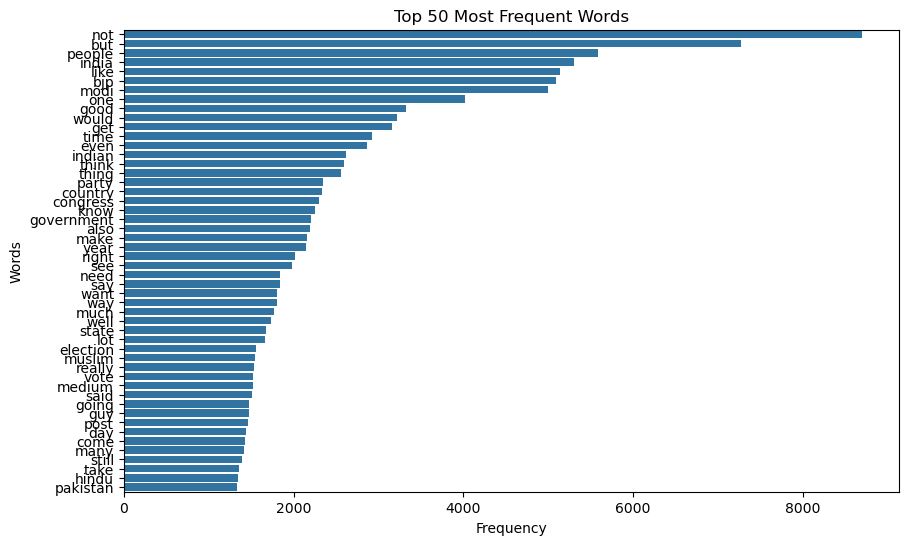

In [641]:
def plot_top_n_words(df, n=20):
    words = ' '.join(df['clean_comment']).split()

    counter = Counter(words)
    most_common_words = counter.most_common(n)

    words, counts = zip(*most_common_words)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(counts), y=list(words))
    plt.title(f'Top {n} Most Frequent Words')
    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.show()

plot_top_n_words(df, n=50)

See not word is used extensivley if we have included that in stop words we would have losed very important data

Now we will find top n words per each category

In [645]:
def plot_top_n_words_by_category(df, n=20, start=0):
    word_category_counts = {}

    for idx, row in df.iterrows():
        words = row['clean_comment'].split()
        category = row['category']  

        for word in words:
            if word not in word_category_counts:
                word_category_counts[word] = { -1: 0, 0: 0, 1: 0 }  

            word_category_counts[word][category] += 1

    total_word_counts = {word: sum(counts.values()) for word, counts in word_category_counts.items()}

    most_common_words = sorted(total_word_counts.items(), key=lambda x: x[1], reverse=True)[start:start+n]
    top_words = [word for word, _ in most_common_words]

    word_labels = top_words
    negative_counts = [word_category_counts[word][-1] for word in top_words]
    neutral_counts = [word_category_counts[word][0] for word in top_words]
    positive_counts = [word_category_counts[word][1] for word in top_words]

    plt.figure(figsize=(12, 8))
    bar_width = 0.75

    plt.barh(word_labels, negative_counts, color='red', label='Negative (-1)', height=bar_width)
    plt.barh(word_labels, neutral_counts, left=negative_counts, color='gray', label='Neutral (0)', height=bar_width)
    plt.barh(word_labels, positive_counts, left=[i+j for i,j in zip(negative_counts, neutral_counts)], color='green', label='Positive (1)', height=bar_width)

    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.title(f'Top {n} Most Frequent Words with Stacked Sentiment Categories')
    plt.legend(title='Sentiment', loc='lower right')
    plt.gca().invert_yaxis()  
    plt.show()

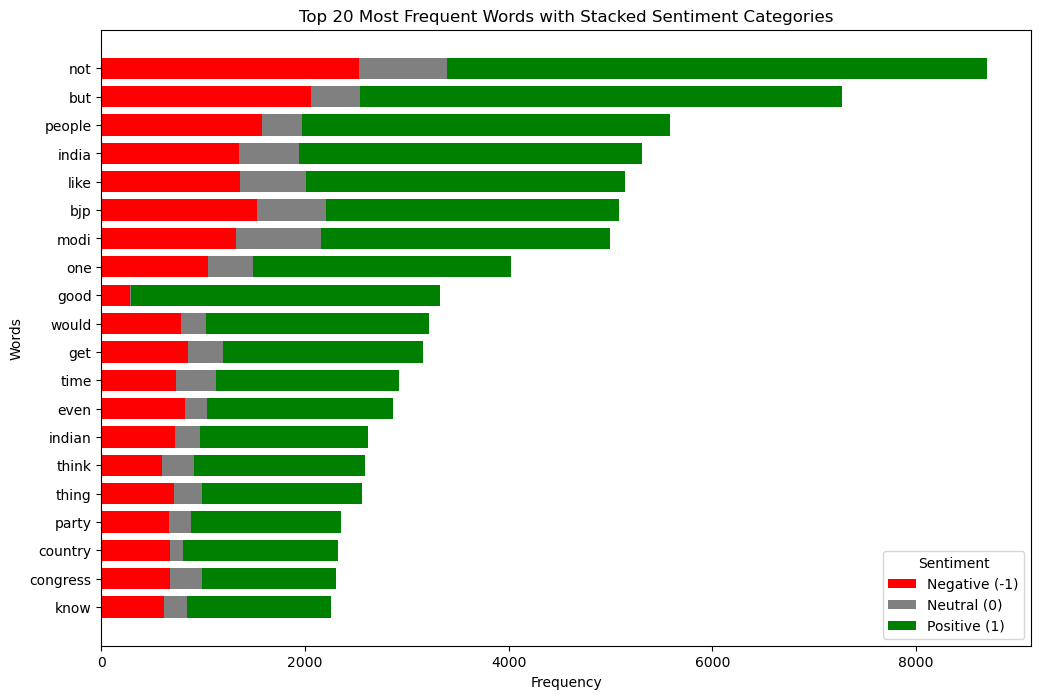

In [647]:
plot_top_n_words_by_category(df, n=20)

Let's save this dataset

In [651]:
df.to_csv("cleaned_data.csv")